# Øving 2

Fouriertransformasjonen er en av de viktigste matematiske verktøyene for å analysere et målt signal, fordi den forteller hvilke og hvor mye av hver frekvens man finner i signalet. Dette er særs nyttig, siden det vi mennesker oppfatter som lyd er periodiske svingninger i lufttrykk, mens lys er periodiske svinginger i det elektromagnetiske feltet. Det er også derfor man lærer om dette i blant annet TTT4120 Digital signalbehandling. Det kommer ikke til å bli noe mindre nyttig i dette faget; denne øvingen fungerer som en oppfriskning i hvordan man gjør Fourieranalyse i Python med NumPy eller SciPy.

## Oppgave 1

In [16]:
import numpy as np
import matplotlib.pyplot as plt

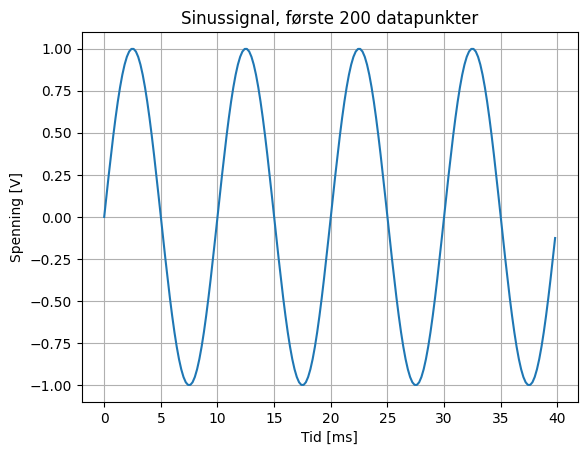

In [17]:
a = 1
f = 100
delta_t = 0.2 * 10**-3
N = 900

t = np.arange(N) * delta_t
x = np.sin(2*np.pi*f*t)

plt.plot(t[:200] * 1000, x[:200])
plt.xlabel("Tid [ms]")
plt.ylabel("Spenning [V]")
plt.title("Sinussignal, første 200 datapunkter")
plt.grid()
plt.show()

In [18]:
f_s = 1 / delta_t
f_nyquist = f_s / 2

print(f"Samplingsfrekvens: {f_s} Hz")
print(f"Nyquist-grense: {f_nyquist} Hz")

Samplingsfrekvens: 5000.0 Hz
Nyquist-grense: 2500.0 Hz


## Oppgave 2

Frekvensoppløsning Δf = 488.28 Hz


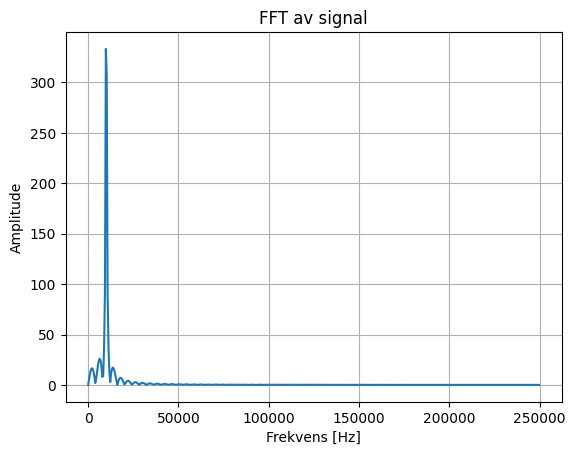

In [19]:
# Oppgave a

N_FFT = 1024
fs = f/delta_t

#FFT
X = np.fft.fft(x, N_FFT)

frekvens = np.linspace(0, fs, N_FFT)

# Frekvensoppløsning
df = fs / N_FFT

print(f"Frekvensoppløsning Δf = {df:.2f} Hz")

# Plot (kun første halvdel gir mening)
plt.plot(frekvens[:N_FFT//2], np.abs(X[:N_FFT//2]))
plt.xlabel("Frekvens [Hz]")
plt.ylabel("Amplitude")
plt.title("FFT av signal")
plt.grid()
plt.show()

Speilfrekvens: 499900 Hz


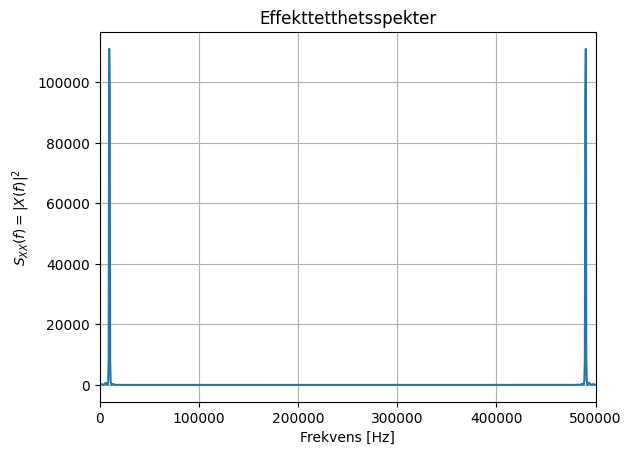

In [20]:
Sxx = np.conj(X) * X
freq = np.arange(N_FFT) * df
print(f"Speilfrekvens: {fs - f:.0f} Hz")

plt.plot(freq, Sxx.real)
plt.xlabel("Frekvens [Hz]")
plt.ylabel(r"$S_{XX}(f)=|X(f)|^2$")
plt.title("Effekttetthetsspekter")
plt.grid()
plt.xlim(0, fs)
plt.show()

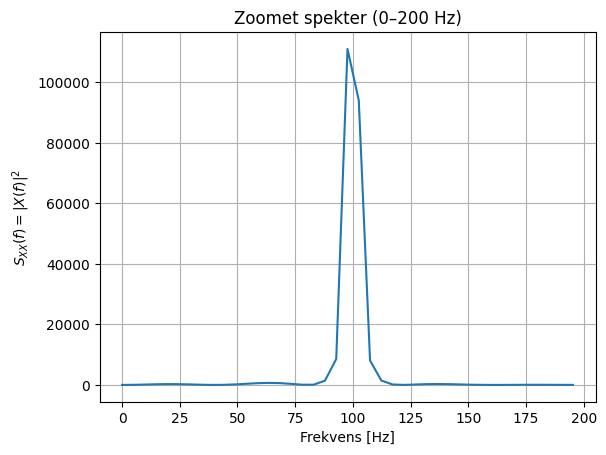

fs = 5000 Hz
df = 4.88 Hz
Topp i 0–200 Hz ved: 97.66 Hz


In [24]:
# Signalparametre
A = 1
f0 = 100          # Hz
dt = 0.2e-3       # s
fs = 1/dt         # 5000 Hz
N = 900
NFFT = 1024

# Lag signal
t = np.arange(N) * dt
x = A * np.sin(2*np.pi*f0*t)

# FFT
X = np.fft.fft(x, NFFT)
Sxx = np.abs(X)**2

# Frekvensakse
df = fs / NFFT
freq = np.arange(NFFT) * df

# Zoom 0–200 Hz
mask = (freq >= 0) & (freq <= 200)

plt.figure()
plt.plot(freq[mask], Sxx[mask])
plt.xlabel("Frekvens [Hz]")
plt.ylabel(r"$S_{XX}(f)=|X(f)|^2$")
plt.title("Zoomet spekter (0–200 Hz)")
plt.grid()
plt.show()

# Finn topp bare i området 0–200 Hz
idx_zoom = np.argmax(Sxx[mask])
f_topp = freq[mask][idx_zoom]

print(f"fs = {fs:.0f} Hz")
print(f"df = {df:.2f} Hz")
print(f"Topp i 0–200 Hz ved: {f_topp:.2f} Hz")

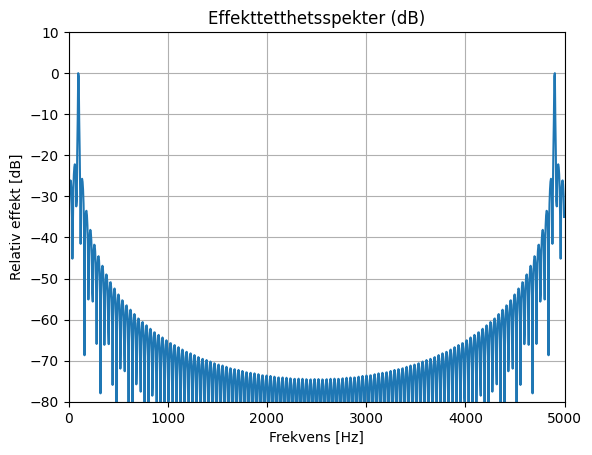

In [25]:
# FFT fra tidligere
X = np.fft.fft(x, NFFT)

# Amplitude
X_abs = np.abs(X)

# Unngå log(0)
X_abs[X_abs == 0] = 1e-12

# dB-skala
X_dB = 20 * np.log10(X_abs)

# Normaliser slik at maks = 0 dB
X_dB = X_dB - np.max(X_dB)

# Frekvensakse
freq = np.arange(NFFT) * (fs / NFFT)

# Plot
plt.plot(freq, X_dB)
plt.xlabel("Frekvens [Hz]")
plt.ylabel("Relativ effekt [dB]")
plt.title("Effekttetthetsspekter (dB)")
plt.ylim([-80, 10])
plt.xlim([0, fs])
plt.grid()
plt.show()

## Oppgave 3

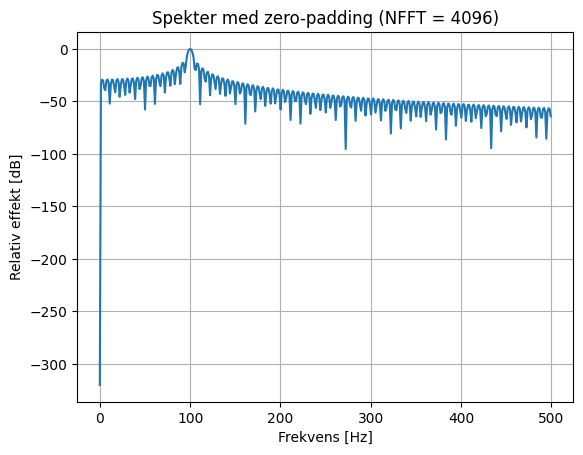

Ny Δf = 1.221 Hz


In [26]:
# Signal (samme som før)
A = 1
f0 = 100
dt = 0.2e-3
fs = 1/dt
N = 900

t = np.arange(N) * dt
x = A * np.sin(2*np.pi*f0*t)

# Zero-padding FFT
NFFT = 4096
X = np.fft.fft(x, NFFT)

# Frekvensakse (VIKTIG!)
df = fs / NFFT
freq = np.arange(NFFT) * df

# dB-spekter
X_abs = np.abs(X)
X_abs[X_abs == 0] = 1e-12
X_dB = 20 * np.log10(X_abs)
X_dB = X_dB - np.max(X_dB)

# Plot (0–500 Hz for oversikt)
mask = (freq >= 0) & (freq <= 500)

plt.plot(freq[mask], X_dB[mask])
plt.xlabel("Frekvens [Hz]")
plt.ylabel("Relativ effekt [dB]")
plt.title("Spekter med zero-padding (NFFT = 4096)")
plt.grid()
plt.show()

print(f"Ny Δf = {df:.3f} Hz")

## Oppgave 4

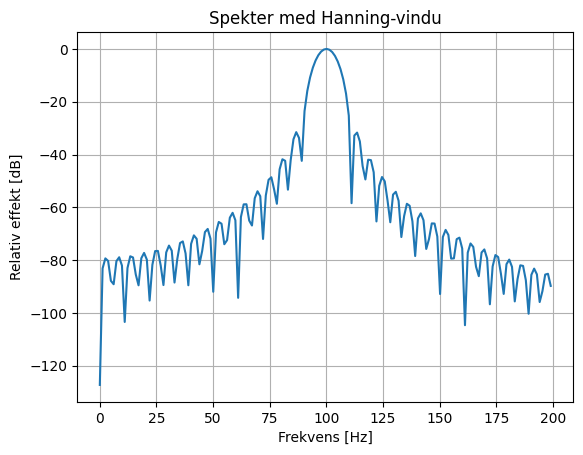

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# Signal (samme som før)
A = 1
f0 = 100
dt = 0.2e-3
fs = 1/dt
N = 900

t = np.arange(N) * dt
x = A * np.sin(2*np.pi*f0*t)

# Hanning-vindu
w = np.hanning(N)

# Vindusfiltrert signal
x_win = x * w

# FFT
NFFT = 4096
X = np.fft.fft(x_win, NFFT)

# Frekvensakse
freq = np.arange(NFFT) * (fs / NFFT)

# dB-spekter
X_abs = np.abs(X)
X_abs[X_abs == 0] = 1e-12
X_dB = 20 * np.log10(X_abs)
X_dB = X_dB - np.max(X_dB)

# Plot (zoom 0–200 Hz)
mask = (freq >= 0) & (freq <= 200)

plt.plot(freq[mask], X_dB[mask])
plt.xlabel("Frekvens [Hz]")
plt.ylabel("Relativ effekt [dB]")
plt.title("Spekter med Hanning-vindu")
plt.grid()
plt.show()

## Oppgave 5

In [32]:
import numpy as np
import matplotlib.pyplot as plt

# Gitte verdier
f = 100             # signalfrekvens [Hz]
dt = 0.2e-3         # samplingstid [s]
fs = 1 / dt         # samplingsfrekvens [Hz]
N = 900             # antall målepunkter
NFFT = 4096         # FFT-lengde

# Tidsakse
t = np.arange(N) * dt

# Vinkelfrekvens
omega = 2 * np.pi * f

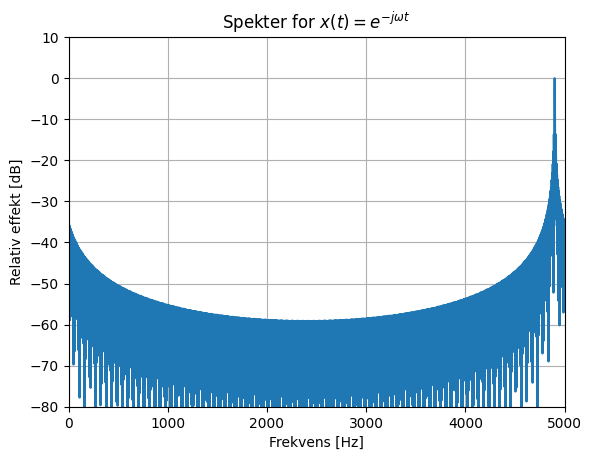

Topp i spekteret for exp(-jωt): 4899.90 Hz


In [33]:
# Kompleks signal med negativt fortegn
x_neg = np.exp(-1j * omega * t)

# FFT
X_neg = np.fft.fft(x_neg, NFFT)

# Frekvensakse fra 0 til fs
freq = np.arange(NFFT) * fs / NFFT

# dB-spekter, normalisert til 0 dB
X_neg_dB = 20 * np.log10(np.abs(X_neg) + 1e-12)
X_neg_dB = X_neg_dB - np.max(X_neg_dB)

# Plot
plt.figure()
plt.plot(freq, X_neg_dB)
plt.xlabel("Frekvens [Hz]")
plt.ylabel("Relativ effekt [dB]")
plt.title(r"Spekter for $x(t)=e^{-j\omega t}$")
plt.xlim(0, fs)
plt.ylim(-80, 10)
plt.grid()
plt.show()

# Finn topp
f_topp_a = freq[np.argmax(np.abs(X_neg))]
print(f"Topp i spekteret for exp(-jωt): {f_topp_a:.2f} Hz")

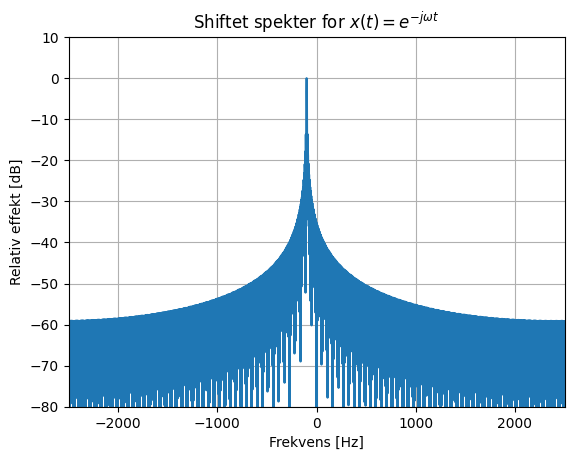

Topp etter fftshift for exp(-jωt): -100.10 Hz


In [37]:
# Flytt FFT slik at negative frekvenser kommer til venstre
X_neg_shift = np.fft.fftshift(X_neg)

# Frekvensakse fra -fs/2 til fs/2
freq_shift = np.fft.fftshift(np.fft.fftfreq(NFFT, d=dt))

# dB-spekter, normalisert
X_neg_shift_dB = 20 * np.log10(np.abs(X_neg_shift) + 1e-12)
X_neg_shift_dB = X_neg_shift_dB - np.max(X_neg_shift_dB)

# Plot
plt.figure()
plt.plot(freq_shift, X_neg_shift_dB)
plt.xlabel("Frekvens [Hz]")
plt.ylabel("Relativ effekt [dB]")
plt.title(r"Shiftet spekter for $x(t)=e^{-j\omega t}$")
plt.xlim(-fs/2, fs/2)
plt.ylim(-80, 10)
plt.grid()
plt.show()

# Finn topp
f_topp_b = freq_shift[np.argmax(np.abs(X_neg_shift))]
print(f"Topp etter fftshift for exp(-jωt): {f_topp_b:.2f} Hz")

In [38]:
# Test med f = 0 Hz
f_test = 0
omega_test = 2 * np.pi * f_test

x_test = np.exp(-1j * omega_test * t)

X_test = np.fft.fft(x_test, NFFT)
X_test_shift = np.fft.fftshift(X_test)

f_topp_test = freq_shift[np.argmax(np.abs(X_test_shift))]
print(f"Topp for f = 0 Hz havner ved: {f_topp_test:.2f} Hz")

Topp for f = 0 Hz havner ved: 0.00 Hz


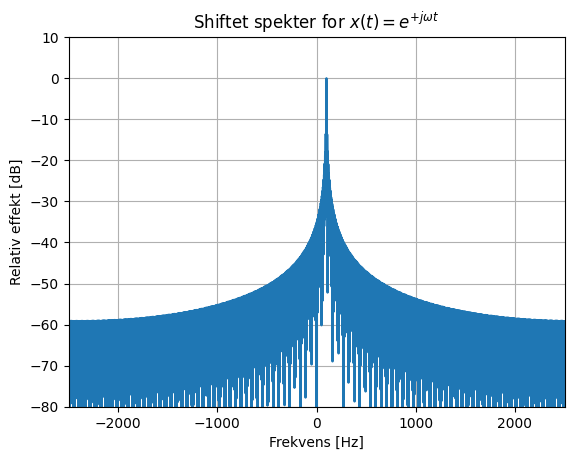

Topp etter fftshift for exp(+jωt): 100.10 Hz


In [39]:
# Kompleks signal med positivt fortegn
x_pos = np.exp(1j * omega * t)

# FFT
X_pos = np.fft.fft(x_pos, NFFT)

# Shift FFT
X_pos_shift = np.fft.fftshift(X_pos)

# dB-spekter, normalisert
X_pos_shift_dB = 20 * np.log10(np.abs(X_pos_shift) + 1e-12)
X_pos_shift_dB = X_pos_shift_dB - np.max(X_pos_shift_dB)

# Plot
plt.figure()
plt.plot(freq_shift, X_pos_shift_dB)
plt.xlabel("Frekvens [Hz]")
plt.ylabel("Relativ effekt [dB]")
plt.title(r"Shiftet spekter for $x(t)=e^{+j\omega t}$")
plt.xlim(-fs/2, fs/2)
plt.ylim(-80, 10)
plt.grid()
plt.show()

# Finn topp
f_topp_c = freq_shift[np.argmax(np.abs(X_pos_shift))]
print(f"Topp etter fftshift for exp(+jωt): {f_topp_c:.2f} Hz")